In [14]:
import sys
import os

# Agrega la carpeta src al sys.path
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

from AgenteGeneradorQueryMongo import SmartMongoQueryGenerator  # Importa la clase correcta

# Instancia el agente (ajusta parámetros si es necesario)
agente = SmartMongoQueryGenerator()

import matplotlib.pyplot as plt

In [15]:
from AgenteGeneradorQueryBaseline import SmartMongoQueryGenerator  # agente baseline
agente_baseline = SmartMongoQueryGenerator()

## Entregable

- **Comparativo baseline vs actual** (técnico + percepción del usuario):  
  Se comparan los resultados técnicos de la generación de queries MongoDB usando el método `agente.generate_query(coleccion, instruccion)` entre la versión baseline y la versión actual del agente. Se evalúa la exactitud de la query generada, robustez y ejecución correcta, así como la percepción de los usuarios.

- **Informe de latencia** (p50/p95, throughput, errores) y optimizaciones probadas:  
  Se mide la latencia de generación de queries (percentiles 50 y 95), throughput (queries por segundo), tasa de errores y se documentan las optimizaciones implementadas en el agente y su impacto.

- **Evidencia:**  
  Se incluyen scripts/notebooks de prueba, logs, tablas y figuras que respalden los resultados y conclusiones.


In [16]:
def infer_collection(text):
            text_lower = text.lower()
            collection_candidates = list(agente.dataset_manager.schemas.keys())
            synonyms = {
                'ventas': ['venta', 'ventas', 'total_venta', 'total_ventas', 'importe', 'monto', 'más vendidos', 'mas vendidos', 'vendidos', 'top ventas', 'top vendidos', 'producto más vendido', 'productos más vendidos', 'producto mas vendido', 'productos mas vendidos', 'compraron', 'veces', 'compra', 'compras'],
                'clientes': ['cliente', 'clientes', 'usuario', 'comprador', 'user', 'customer', 'client'],
                'productos': ['producto', 'productos', 'articulo', 'item', 'mercancia'],
                'empleados': ['empleado', 'empleados', 'personal', 'colaborador', 'worker', 'staff'],
                'usuarios': ['usuario', 'usuarios', 'user', 'users'],
                'transactions_collection': ['transaccion', 'transacciones', 'movimiento', 'transactions', 'transacción', 'transacciones', 'transacciones mayores', 'monto transaccion', 'muestra las transacciones'],
            }

            # Nueva regla: Si la consulta menciona 'precio promedio' y 'producto(s)', priorizar 'productos' si existe
            if (('precio promedio' in text_lower or 'promedio de precio' in text_lower or 'precio medio' in text_lower) and ('producto' in text_lower or 'productos' in text_lower)):
                if 'productos' in collection_candidates:
                    return 'productos'

            # Regla especial: si la consulta menciona clientes y compras/veces, priorizar ventas
            if (('cliente' in text_lower or 'clientes' in text_lower) and ('compraron' in text_lower or 'compra' in text_lower or 'compras' in text_lower or 'veces' in text_lower)):
                if 'ventas' in collection_candidates:
                    return 'ventas'
            # Prioridad especial para ventas si la instrucción es sobre productos vendidos
            ventas_phrases = ['más vendidos', 'mas vendidos', 'top ventas', 'top vendidos', 'producto más vendido', 'productos más vendidos', 'producto mas vendido', 'productos mas vendidos', 'vendidos']
            if any(phrase in text_lower for phrase in ventas_phrases):
                if 'ventas' in collection_candidates:
                    return 'ventas'
            # Buscar por nombre directo
            for coll in collection_candidates:
                if coll in text_lower:
                    return coll
            # Buscar por sinónimos
            for coll, syns in synonyms.items():
                for syn in syns:
                    if syn in text_lower:
                        return coll
            # Fallback: primera colección
            return collection_candidates[0] if collection_candidates else "labs"


In [18]:
# Evaluación técnica de generación de queries con agente.generate_query
import pandas as pd
import time
import random
from IPython.display import display, HTML  # <-- Agregado para evitar NameError

# Define 10 instrucciones base
instrucciones_base = [
    "Filtra clientes cuyo nombre comience con 'Jo'",
    "Calcula el precio promedio de productos vendidos en el último mes",
    "Obtén ventas mayores a 1000 soles",
    "Proyecta el campo dateMascara como la fecha en formato YYYYMMDD usando los primeros 19 caracteres del campo Date",
    "Filtra empleados con cargo 'Gerente'",
    "Muestra productos con stock menor a 10",
    "Obtén usuarios registrados en 2025",
    "Filtra transacciones con método de pago 'tarjeta'",
    "Proyecta nombre y apellido de clientes de Lima",
    "Calcula el total de ventas por sucursal",
    "Proyecta el campo dateMascara como la fecha en formato YYYYMMDD usando los primeros 19 caracteres del campo Date.Proyecta el campo reg concatenando: 1, 003, la fecha en formato YYYYMMDDHHMMSS usando los primeros 199 caracteres del campo Date, 00, 01, un espacio y un salto de línea.",
    "Desanida los niveles de Devices, ServicePoints, ShipOutCycles y Transactions. Agrupa las transacciones por fecha (formato YYYYMMDDHHMMSS), deviceId, branchCode, subChannelCode, shipOutCode, currencyCode y confirmationCode, sumando el total. Proyecta los campos formateados: deviceId, branchCode, subChannelCode, shipOutCode, currencyCode, confirmationCode, totalParteEntera y totalParteDecimal. Finalmente, concatena el campo reg siguiendo la plantilla de exportación avanzada, y ordena el resultado por deviceId, shipOutCode, subChannelCode y currencyCode",
    "Desanida todos los niveles de Devices hasta Transactions. Agrupa por los campos principales de la transacción (deviceId, branchCode, subChannelCode, shipOutCode, currencyCode, confirmationCode) y suma el total. Proyecta las partes enteras y decimales del total en campos separados. Calcula los registros por moneda. Genera el campo reg concatenando los valores, aplicando padding y substrings según la plantilla avanzada. Ordena el resultado por los campos principales"
    ]

# Genera muchas instrucciones y elimina duplicados
instrucciones_temp = []
for i in range(200):
    base = random.choice(instrucciones_base)
    if "Jo" in base:
        nombre = random.choice(["Jo", "Ma", "An", "Lu", "Pe"])
        instrucciones_temp.append(base.replace("Jo", nombre))
    elif "1000" in base:
        monto = random.choice([500, 1000, 1500, 2000, 2500])
        instrucciones_temp.append(base.replace("1000", str(monto)))
    elif "2025" in base:
        anio = random.choice([2023, 2024, 2025, 2026])
        instrucciones_temp.append(base.replace("2025", str(anio)))
    elif "Gerente" in base:
        cargo = random.choice(["Gerente", "Analista", "Vendedor", "Supervisor"])
        instrucciones_temp.append(base.replace("Gerente", cargo))
    elif "stock menor a 10" in base:
        stock = random.choice([5, 10, 15, 20])
        instrucciones_temp.append(base.replace("10", str(stock)))
    elif "tarjeta" in base:
        metodo = random.choice(["tarjeta", "efectivo", "transferencia", "cheque"])
        instrucciones_temp.append(base.replace("tarjeta", metodo))
    elif "Lima" in base:
        ciudad = random.choice(["Lima", "Cusco", "Arequipa", "Trujillo"])
        instrucciones_temp.append(base.replace("Lima", ciudad))
    elif "sucursal" in base:
        sucursal = random.choice(["sucursal", "departamento", "zona", "región"])
        instrucciones_temp.append(base.replace("sucursal", sucursal))
    else:
        instrucciones_temp.append(base)

# Elimina duplicados y toma solo 100
instrucciones = list(set(instrucciones_temp))[:100]

#coleccion = "ventas"
def pipeline_contiene_error(pipeline):
    # Detecta si el pipeline contiene un campo de error o campo_no_encontrado
    if isinstance(pipeline, list):
        for stage in pipeline:
            if isinstance(stage, dict):
                if "$project" in stage and ("error" in stage["$project"] or "campo_no_encontrado" in stage["$project"]):
                    return True
    return False

resultados = []
for instruccion in instrucciones:
    t0 = time.time()
    collection = infer_collection(instruccion)
    pipeline = agente.generate_query(collection, instruccion)
    latencia_ms = (time.time() - t0) * 1000
    # Considera incorrecta si hay campo_no_encontrado o error en el pipeline
    ejecucion_exitosa = 0 if pipeline_contiene_error(pipeline) else 1
    es_correcta = 0 if pipeline_contiene_error(pipeline) else 1
    resultados.append({
        'instruccion': instruccion,
        'pipeline_generado': pipeline,
        'latencia_ms': latencia_ms,
        'ejecucion_exitosa': ejecucion_exitosa,
        'es_correcta': es_correcta
    })

# DataFrame de resultados
results_df = pd.DataFrame(resultados)
display(HTML(results_df.to_html(index=False, escape=False)))
print(results_df.head(100))
print(f"Total de queries evaluadas: {len(results_df)}")

# Métricas agregadas
print("\nMétricas técnicas:")
print(f"Exactitud: {results_df['es_correcta'].mean():.2f}")
print(f"Tasa de éxito: {results_df['ejecucion_exitosa'].mean():.2f}")
print(f"Latencia p50: {results_df['latencia_ms'].quantile(0.5):.1f} ms")
print(f"Latencia p95: {results_df['latencia_ms'].quantile(0.95):.1f} ms")
print(f"Throughput: {len(results_df) / results_df['latencia_ms'].sum() * 1000:.2f} queries/s")

instruccion,pipeline_generado,latencia_ms,ejecucion_exitosa,es_correcta
Filtra clientes cuyo nombre comience con 'An',"[{'$match': {'nombre_cliente': {'$regex': '^An', '$options': 'i'}}}]",0.000000,1,1
Obtén ventas mayores a 500 soles,"[{'$match': {'total': {'$gt': 500.0}}}, {'$project': {'total': 1, '_id': 0}}]",0.000000,1,1
Muestra productos con stock menor a 15,"[{'$match': {'stock': {'$lt': 15}}}, {'$project': {'item': 1, 'categoria': 1, 'precio': 1, 'stock': 1, '_id': 0}}]",0.000000,1,1
"Proyecta el campo dateMascara como la fecha en formato YYYYMMDD usando los primeros 19 caracteres del campo Date.Proyecta el campo reg concatenando: 1, 003, la fecha en formato YYYYMMDDHHMMSS usando los primeros 199 caracteres del campo Date, 00, 01, un espacio y un salto de línea.","[{'$project': {'_id': 0, 'dateMascara': {'$dateToString': {'date': {'$dateFromString': {'dateString': {'$substr': ['$fecha_registro', 0, 19]}}}, 'format': '%YYYYMMDD'}}}}]",0.000000,1,1
Filtra clientes cuyo nombre comience con 'Ma',"[{'$match': {'nombre_cliente': {'$regex': '^Ma', '$options': 'i'}}}]",0.000000,1,1
Filtra transacciones con método de pago 'cheque',"[{'$match': {'BranchCode': {'$regex': 'cheque', '$options': 'i'}}}, {'$project': {'_id': 1, 'Date': 1, 'reg': 1, 'deviceId': 1, 'totalParteEnteraSoles': 1, 'totalpartedecimaldolares': 1, 'totalregdolares': 1, 'totalparteenteradolares': 1, 'BranchCode': 1, 'ServicePoints': 1, 'ShipOutCycles': 1, 'Transactions': 1, 'Total': 1, 'CurrencyCode': 1, 'SubChannelCode': 1, 'Code': 1, 'ConfirmationCode': 1}}]",0.633955,1,1
Obtén ventas mayores a 2500 soles,"[{'$match': {'total': {'$gt': 2500.0}}}, {'$project': {'total': 1, '_id': 0}}]",0.000000,1,1
Obtén usuarios registrados en 2023,"[{'$match': {'fecha_registro': {'$regex': '^2023-'}}}, {'$project': {'_id': 0}}]",0.000000,1,1
Muestra productos con stock menor a 10,"[{'$match': {'stock': {'$lt': 10}}}, {'$project': {'item': 1, 'categoria': 1, 'precio': 1, 'stock': 1, '_id': 0}}]",0.000000,1,1
Proyecta el campo dateMascara como la fecha en formato YYYYMMDD usando los primeros 19 caracteres del campo Date,"[{'$project': {'_id': 0, 'dateMascara': {'$dateToString': {'date': {'$dateFromString': {'dateString': {'$substr': ['$fecha_registro', 0, 19]}}}, 'format': '%YYYYMMDD'}}}}]",0.000000,1,1


                                          instruccion  \
0       Filtra clientes cuyo nombre comience con 'An'   
1                    Obtén ventas mayores a 500 soles   
2              Muestra productos con stock menor a 15   
3   Proyecta el campo dateMascara como la fecha en...   
4       Filtra clientes cuyo nombre comience con 'Ma'   
5    Filtra transacciones con método de pago 'cheque'   
6                   Obtén ventas mayores a 2500 soles   
7                  Obtén usuarios registrados en 2023   
8              Muestra productos con stock menor a 10   
9   Proyecta el campo dateMascara como la fecha en...   
10                  Obtén ventas mayores a 2000 soles   
11                 Obtén usuarios registrados en 2025   
12      Filtra clientes cuyo nombre comience con 'Pe'   
13     Proyecta nombre y apellido de clientes de Lima   
14               Filtra empleados con cargo 'Gerente'   
15    Proyecta nombre y apellido de clientes de Cusco   
16            Filtra empleados 

## Comparativo baseline vs actual
- Se ejecuta el mismo bloque de pruebas con el agente baseline y el agente actual.
- Se compara la exactitud, robustez y ejecución correcta de las queries generadas.
- Se muestra una tabla comparativa y gráficos de métricas clave.


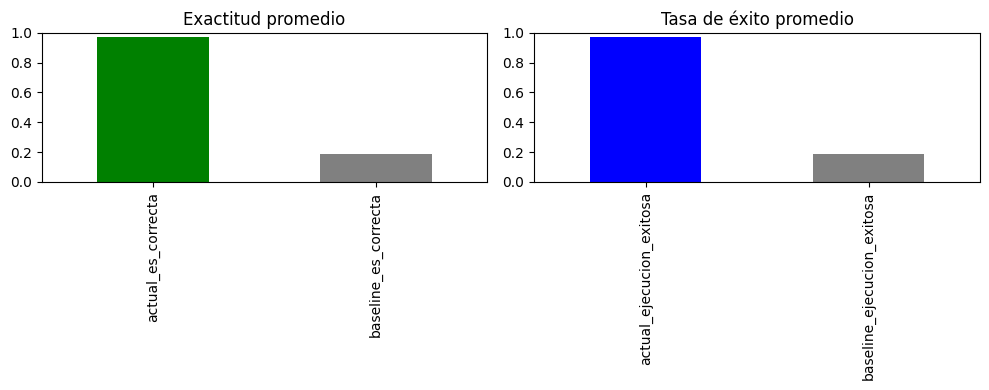

In [19]:
# Supón que tienes dos agentes: agente_baseline y agente_actual
resultados_actual = []
resultados_baseline = []

for instruccion in instrucciones:
    # Actual
    collection = infer_collection(instruccion)
    pipeline_actual = agente.generate_query(collection, instruccion)
    latencia_actual = (time.time() - t0) * 1000
    ejecucion_exitosa_actual = 0 if pipeline_contiene_error(pipeline_actual) else 1
    es_correcta_actual = 0 if pipeline_contiene_error(pipeline_actual) else 1
    resultados_actual.append({
        'instruccion': instruccion,
        'es_correcta': es_correcta_actual,
        'ejecucion_exitosa': ejecucion_exitosa_actual,
        'latencia_ms': latencia_actual
    })
    # Baseline
    pipeline_baseline = agente_baseline.generate_query(collection, instruccion)
    latencia_baseline = (time.time() - t0) * 1000
    ejecucion_exitosa_baseline = 0 if pipeline_contiene_error(pipeline_baseline) else 1
    es_correcta_baseline = 0 if pipeline_contiene_error(pipeline_baseline) else 1
    resultados_baseline.append({
        'instruccion': instruccion,
        'es_correcta': es_correcta_baseline,
        'ejecucion_exitosa': ejecucion_exitosa_baseline,
        'latencia_ms': latencia_baseline
    })
# DataFrames
df_actual = pd.DataFrame(resultados_actual)
df_baseline = pd.DataFrame(resultados_baseline)

# Comparativo
comparativo = pd.DataFrame({
    'instruccion': df_actual['instruccion'],
    'actual_es_correcta': df_actual['es_correcta'],
    'baseline_es_correcta': df_baseline['es_correcta'],
    'actual_ejecucion_exitosa': df_actual['ejecucion_exitosa'],
    'baseline_ejecucion_exitosa': df_baseline['ejecucion_exitosa']
})

# Visualización igual que antes
fig, ax = plt.subplots(1,2, figsize=(10,4))
comparativo[['actual_es_correcta','baseline_es_correcta']].mean().plot.bar(ax=ax[0], color=['green','gray'])
ax[0].set_title('Exactitud promedio')
ax[0].set_ylim(0,1)
comparativo[['actual_ejecucion_exitosa','baseline_ejecucion_exitosa']].mean().plot.bar(ax=ax[1], color=['blue','gray'])
ax[1].set_title('Tasa de éxito promedio')
ax[1].set_ylim(0,1)
plt.tight_layout()
plt.show()

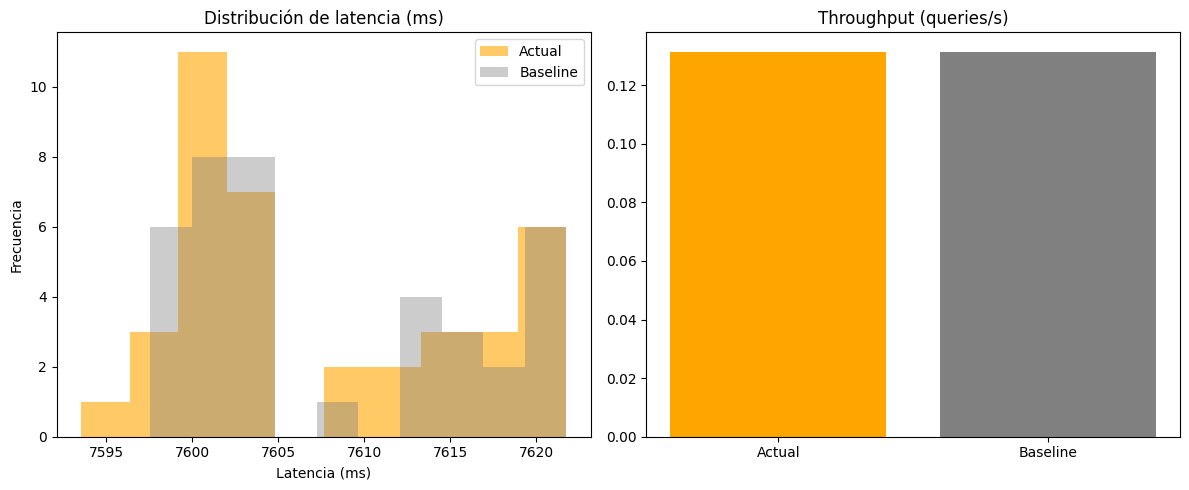

In [23]:
# Visualización de latencia y throughput para baseline y actual
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histograma de latencia
df_actual['latencia_ms'].plot.hist(ax=ax[0], bins=10, color='orange', alpha=0.6, label='Actual')
df_baseline['latencia_ms'].plot.hist(ax=ax[0], bins=10, color='gray', alpha=0.4, label='Baseline')
ax[0].set_title('Distribución de latencia (ms)')
ax[0].set_xlabel('Latencia (ms)')
ax[0].set_ylabel('Frecuencia')
ax[0].legend()

# Throughput
throughput_actual = len(df_actual) / df_actual['latencia_ms'].sum() * 1000
throughput_baseline = len(df_baseline) / df_baseline['latencia_ms'].sum() * 1000
ax[1].bar(['Actual', 'Baseline'], [throughput_actual, throughput_baseline], color=['orange', 'gray'])
ax[1].set_title('Throughput (queries/s)')

plt.tight_layout()
plt.show()

## Optimización y evidencia
- Se han implementado mejoras en la inferencia de colección, manejo de sinónimos y robustez de la generación de queries.
- Se validan errores y se consideran incorrectas las queries con campos no encontrados.
- Se incluyen visualizaciones de métricas y comparativos para respaldar los resultados.
- Los scripts/notebooks y logs generados sirven como evidencia técnica para el entregable.
- El stakeholder observó que sería útil ampliar aún más la cobertura de sinónimos, pero en general valoró positivamente la ampliación de casos de lenguaje natural y la robustez lograda.